In [13]:
import torch
from torch.utils.data import DataLoader, random_split
from torch.optim import Adam
from torchvision import transforms
from copy import deepcopy

from tqdm.auto import tqdm

import matplotlib.pyplot as plt

import sqlite3
import pandas as pd

import subprocess
from datetime import datetime

from pathlib import Path
import sys

ROOT = Path.cwd().parents[1]
sys.path.append(str(ROOT))

from src.config.paths import EMBEDS_DIR, RESULTS, DB_PATH, MODEL_DIR
EMBED_PATH = EMBEDS_DIR/ "cont_embeds.pt"
EMBED_NAME = EMBED_PATH.stem

RESULTS_DIR = RESULTS / EMBED_NAME

In [14]:
contrastive_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.1,
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

In [15]:
conn = sqlite3.connect(DB_PATH)

df = pd.read_sql_query("""
    SELECT path, split
    FROM meta
""", conn)

categories = pd.read_sql_query("SELECT DISTINCT category FROM meta", conn)["category"].to_list()

conn.close()

train_paths = df[df["split"] == "train"]["path"].to_list()
test_paths = df[df["split"] != "train"]["path"].to_list()

In [16]:
print(torch.__version__)
print(torch.version.cuda)
print(torch.cuda.is_available())
print(torch.cuda.device_count())

2.12.0+cu130
13.0
True
1


In [17]:
device = "cuda" if torch.cuda.is_available() else "cpu"

print(f"Device: {device}")

Device: cuda


In [18]:
dino = torch.hub.load(
            "facebookresearch/dinov2",
            "dinov2_vits14"
        )

dino.to(device)
dino.eval()

for p in dino.parameters():
    p.requires_grad = False

Using cache found in /home/ciaran/.cache/torch/hub/facebookresearch_dinov2_main


In [19]:
%load_ext autoreload
%autoreload 2

from src.fine_tune import ModelData, ProjectionHead, BatchSampler, train_one_epoch, evaluate

from src.fine_tune.losses.combined_loss import CombinedLoss

git_commit = subprocess.check_output(
    ["git", "rev-parse", "HEAD"],
    text=True
).strip()


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
LOSSES = {
    "category_cont" : True,
    "preservation": True
}

WEIGHTS = {
    "category_cont" : 1.0,
    "preservation": 0.5
}

NOTES = [
    "Changed to use a residual connection"
]

In [21]:
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

SEED = 42

NUM_WORKERS = 8
PIN_MEMORY = device == "cuda"
SAMPLES_PER_CATEGORY = 16

BATCH_SIZE = len(categories) * SAMPLES_PER_CATEGORY

EPOCHS = 20

DIM = 384
HIDDEN_DIM = 768

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

MODEL_NORMALISER = "layer"

MODEL_NAME = f"{timestamp}_combined_loss_model.pt"

In [22]:
MODEL_INFO = {
    "losses" : LOSSES,
    "weights" : WEIGHTS,
    "notes" : NOTES,
    "git_commit" : git_commit,
    "parameters" : {
        "batch_size" : 256,
        "epochs" : EPOCHS,
        "samples_per_category" : SAMPLES_PER_CATEGORY,

        "model_dim" : DIM,
        "hidden_dim": HIDDEN_DIM,
        "model_normaliser": MODEL_NORMALISER,

        "learning_rate" : LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        
        "num_workers" : NUM_WORKERS,
        "pin_memory" : PIN_MEMORY,

        "random_seed" : SEED
    }
}

In [23]:
category_to_id = {category: idx for idx, category in enumerate(categories)}

dataset = ModelData(train_paths, root=ROOT, category_to_id=category_to_id, transform=contrastive_transform)
test_set = ModelData(test_paths, root=ROOT, category_to_id=category_to_id, transform=test_transform)

train_split = int(len(dataset) * 0.95)
val_split = len(dataset) - train_split

generator = torch.Generator().manual_seed(SEED)

train_set, val_set = random_split(
    dataset,
    [train_split, val_split],
    generator=generator
)

train_labels = [dataset.labels[i] for i in train_set.indices]
val_labels = [dataset.labels[i] for i in val_set.indices]

train_sampler = BatchSampler(
    labels=train_labels,
    samples_per_cat=SAMPLES_PER_CATEGORY,
    seed=None
)

val_sampler = BatchSampler(
    labels=val_labels,
    samples_per_cat=SAMPLES_PER_CATEGORY,
    seed=SEED
)

train_loader = DataLoader(
    train_set,
    batch_sampler=train_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

val_loader = DataLoader(
    val_set,
    batch_sampler=val_sampler,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

test_loader = DataLoader(
    test_set,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

In [24]:
model = ProjectionHead(dim=DIM, hidden_dim=HIDDEN_DIM, norm_type=MODEL_NORMALISER).to(device)

optimizer = Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
criterion = CombinedLoss(enabled=LOSSES, weights=WEIGHTS)

In [25]:

results = pd.DataFrame(columns=["epoch", "train_loss", "val_loss", "gap"])

best_val = float("inf")
best_state = None

try:
    for epoch in tqdm(range(EPOCHS)):
        train_loss = train_one_epoch(model, dino, train_loader, criterion, optimizer, device)
        val_loss = evaluate(model, dino, val_loader, criterion, device)

        if val_loss < best_val:
            best_val = val_loss
            best_state = deepcopy(model.state_dict())
            
        results.loc[len(results)] = {
            "epoch": epoch+1,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "gap": abs(val_loss - train_loss)
        }
        
        print(results.tail(1).to_string(
            index=False,
            header=(epoch==0)
        ) + "\n")

finally:
    if best_state is not None:
        checkpoint = {
            "model_state_dict" : best_state,
            "model_info" : MODEL_INFO,
        }
        torch.save(checkpoint, MODEL_DIR / MODEL_NAME)
        print(f"Best Model Saved (val_loss={best_val:.4f})")

  0%|          | 0/20 [00:00<?, ?it/s]

same=0.8399, different=0.2662, gap=0.5738
Gradient Norm: 0.885999466576922
Paramter change: 0.0009999057510867715
same=0.8987, different=0.1044, gap=0.7943
Gradient Norm: 0.3224788246809985
Paramter change: 0.0007091911393217742
same=0.9345, different=0.0623, gap=0.8722
Gradient Norm: 0.16310275118689918
Paramter change: 0.0005787066766060889
same=0.9539, different=0.0563, gap=0.8976
Gradient Norm: 0.11357242724638773
Paramter change: 0.0004906286485493183
same=0.9630, different=0.0617, gap=0.9013
Gradient Norm: 0.08976815312105685
Paramter change: 0.000429209932917729
same=0.9689, different=0.0718, gap=0.8971
Gradient Norm: 0.06582326480438326
Paramter change: 0.00037730811163783073
same=0.9699, different=0.0809, gap=0.8890
Gradient Norm: 0.19356877842917766
Paramter change: 0.0003352052881382406
same=0.9753, different=0.0904, gap=0.8849
Gradient Norm: 0.04519693203672139
Paramter change: 0.0002998975105583668
same=0.9794, different=0.0947, gap=0.8847
Gradient Norm: 0.0694740861081164

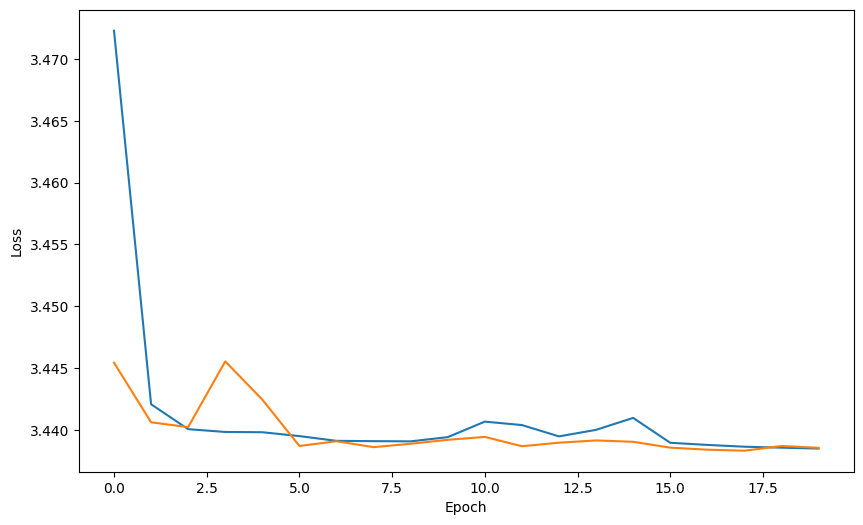

In [26]:
fig = plt.figure(figsize=(10, 6))

plt.plot(range(EPOCHS), results["train_loss"])
plt.plot(range(EPOCHS), results["val_loss"])

plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.show()